# Keşif

In [1]:
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import os

## Veriyi Al

In [2]:
from olist.data import Olist
data = Olist().get_data()

Olist e-ticaret platformundaki her işlem şu özelliklere sahiptir:
- satın alacak olan bir `customer_id`...
- çeşitli `product_id`...
- bir `seller_id`...
- ve bir `review_id`...
- tüm bunlar bir `order_id`'ye aittir.

## Çeşitli DataFrame'lerinizin kardinalitelerini araştırın

❓ **Kaç tane benzersiz `orders`, `reviews`, `sellers`, `products` and `customers` var ?**

In [5]:
# 1. Hangi tablolara sahip olduğumuzu görelim (Anahtarları kontrol et)
print("Tablo Listesi:", data.keys())
print("-" * 30)

Tablo Listesi: dict_keys(['sellers', 'product_category_name_translation', 'orders', 'order_items', 'customers', 'geolocation', 'order_payments', 'order_reviews', 'products'])
------------------------------


In [6]:
# 2. Her tablodaki benzersiz (unique) ID sayılarını yazdıralım.
# nunique() fonksiyonunu kullanıyoruz.

print(f"Unique Orders (Siparişler): {data['orders']['order_id'].nunique()}")
print(f"Unique Reviews (Yorumlar): {data['order_reviews']['review_id'].nunique()}")
print(f"Unique Sellers (Satıcılar): {data['sellers']['seller_id'].nunique()}")
print(f"Unique Products (Ürünler): {data['products']['product_id'].nunique()}")
print(f"Unique Customers (Müşteriler): {data['customers']['customer_id'].nunique()}")

Unique Orders (Siparişler): 99441
Unique Reviews (Yorumlar): 98410
Unique Sellers (Satıcılar): 3095
Unique Products (Ürünler): 32951
Unique Customers (Müşteriler): 99441


❓ **Sipariş başına kaç tane yorum(reviews) var? Tüm siparişler için yorum var mı?**
<details>
    <summary markdown=‘span’>İpuçları</summary>

Bu bilgiye bireysel csv dosyanızdan doğrudan erişemezsiniz. Öğrenmek için tabloları birleştirmeniz gerekir. Hangi tür birleştirme yapmanız gerektiğini düşünün.

Hangi tablolara ihtiyacınız olduğundan emin değil misiniz? Öğrenmek için ERD'nize geri dönün.

Yorum sayısını öğrenmek için: `order_id` başına yorum sayısını sayın ve bir histogram çizin. Pandas serisinde `.hist()` kullanabilirsiniz.
</details>

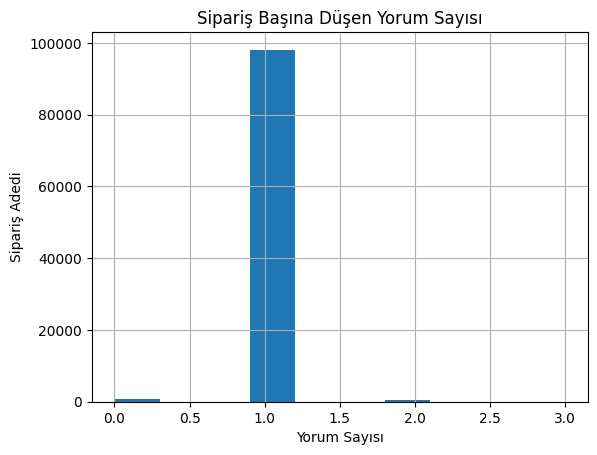

Yorum Sayıları Dağılımı:
 review_id
1    98126
0      768
2      543
3        4
Name: count, dtype: int64


In [10]:
import matplotlib.pyplot as plt

# 1. Tabloları değişkenlere alalım (Daha temiz kod için)
orders = data['orders']
reviews = data['order_reviews']

# 2. Tabloları Birleştir (Merge)
# 'how=left' diyerek "Soldaki (Orders) tablosundaki her şeyi tut" diyoruz.
# Böylece yorumu OLMAYAN siparişler de listede kalacak (karşısı boş/NaN olacak).
orders_with_reviews = orders.merge(reviews, on='order_id', how='left')

# 3. Sipariş başına yorum sayısını say
# count() metodu boş (NaN) değerleri saymaz. Yani yorum yoksa 0 sonucunu verir.
reviews_per_order = orders_with_reviews.groupby('order_id')['review_id'].count()

# 4. Sonucu Görselleştir (Histogram)
reviews_per_order.hist()
plt.title("Sipariş Başına Düşen Yorum Sayısı")
plt.xlabel("Yorum Sayısı")
plt.ylabel("Sipariş Adedi")
plt.show()

# 5. Sayısal Kanıt
print("Yorum Sayıları Dağılımı:\n", reviews_per_order.value_counts())

🧪 **Test your code below**

Yorum eksik olan siparişlerin sayısını `int` olarak `n_missing_reviews` adlı bir değişkende saklayın.

In [11]:
n_missing_reviews = orders_with_reviews['review_id'].isna().sum()
print(f"Number of orders without reviews: {n_missing_reviews}")

Number of orders without reviews: 768


In [12]:
from nbresult import ChallengeResult

result = ChallengeResult('exploratory',
    n=n_missing_reviews
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/berkayturhan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/berkayturhan/data-exploratory-analysis/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_exploratory.py::TestExploratory::test_n_missing_reviews PASSED      [100%]

============================== 1 passed in 0.15s ===============================


💯 You can commit your code:

git add tests/exploratory.pickle

git commit -m 'Completed exploratory step'

git push origin master

